# Clustering Algorithms in Finance: A Beginner's Guide

Clustering is an **unsupervised machine learning** technique: you give the algorithm a set of data points and ask it to discover natural groups (clusters) — without telling it in advance what those groups are.

## Why clustering matters in finance

| Application | What you group | What the clusters tell you |
|---|---|---|
| **Portfolio construction** | Stocks | Build diversified portfolios by picking one from each cluster |
| **Peer group analysis** | Companies | Compare a stock's valuation to genuinely similar firms, not just its stated sector |
| **Regime detection** | Market states | Identify bull, bear, or sideways environments from historical data |
| **Risk factor discovery** | Return time-series | Find hidden co-movement patterns not captured by standard risk models |
| **Fraud / anomaly detection** | Transactions | Flag records that do not belong to any normal cluster |

## What you will learn

1. **Mock data generation** — 40 synthetic stocks with 6 realistic financial features across 5 sectors
2. **Feature preprocessing** — why standardisation is essential before any distance-based algorithm
3. **PCA** — reduce 6 features to 2–3 principal components and visualise the dataset
4. **K-Means** — the classic partition algorithm with elbow / silhouette tuning
5. **Hierarchical clustering** — dendrograms and Ward linkage for portfolio grouping
6. **DBSCAN** — density-based clustering that flags outliers automatically
7. **Gaussian Mixture Models (GMM)** — soft probabilistic cluster membership
8. **Algorithm comparison** — side-by-side evaluation with silhouette scores and Adjusted Rand Index

## Modeling assumptions
- Fully synthetic data; sector labels are used only as a *validation benchmark*, not as input to the algorithms
- All algorithms operate on the same scaled feature matrix so comparisons are fair
- No survivorship bias, no real market data — this is a teaching sandbox


In [4]:
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RNG = np.random.default_rng(42)
print("Libraries loaded.")


Libraries loaded.


## 1. Mock Financial Dataset

We create **40 synthetic stocks** across 5 sectors (8 stocks each). Each stock has 6 financial features:

| Feature | What it measures | Finance intuition |
|---|---|---|
| `annual_return` | Average yearly return (%) | How much did the stock appreciate? |
| `volatility` | Annualised standard deviation of returns | How wildly does it move? |
| `beta` | Sensitivity to the overall market | Does it amplify or dampen market moves? |
| `pe_ratio` | Price ÷ earnings per share | How expensive is the stock relative to its profits? |
| `dividend_yield` | Annual dividend ÷ price | How much income does it pay? |
| `max_drawdown` | Worst peak-to-trough decline | What is the worst case loss an investor faced? |

### Sector archetypes (how the mock data is designed)

| Sector | Return | Volatility | Beta | P/E | Dividend | Max DD | Profile |
|---|---|---|---|---|---|---|---|
| Technology | High | High | High | High | Low | High | Growth, aggressive |
| Financials | Medium | Medium | Medium | Low | Medium-high | Medium | Value, income |
| Healthcare | Medium-high | Medium | Low | High | Low | Medium | Defensive growth |
| Energy | Low | High | Medium | Low | High | High | Cyclical, income |
| Consumer | Low | Low | Low | Medium | Medium | Low | Defensive, stable |

Each stock's features are drawn from its sector archetype plus Gaussian noise, so there is meaningful structure but also realistic overlap between sectors.


In [2]:
# ── Sector archetypes: [annual_return, volatility, beta, pe_ratio, dividend_yield, max_drawdown]
SECTORS = ["Technology", "Financials", "Healthcare", "Energy", "Consumer"]
N_PER   = 8

ARCHETYPE = {
    #                    return  vol   beta   PE    DY    MDD
    "Technology": np.array([ 0.22,  0.32,  1.40, 30.0,  0.5,  0.35]),
    "Financials": np.array([ 0.12,  0.20,  1.10, 12.0,  2.8,  0.28]),
    "Healthcare": np.array([ 0.16,  0.22,  0.70, 25.0,  1.2,  0.25]),
    "Energy":     np.array([ 0.09,  0.30,  1.20,  8.0,  4.0,  0.38]),
    "Consumer":   np.array([ 0.08,  0.16,  0.60, 18.0,  2.5,  0.20]),
}
NOISE_STD = np.array([0.04, 0.04, 0.15, 3.0, 0.40, 0.04])
CLIP_LOW  = np.array([-0.30, 0.05, 0.10,  2.0, 0.0, 0.05])
CLIP_HIGH = np.array([ 0.80, 0.70, 3.00, 80.0, 8.0, 0.80])

rows = []
for sec, arch in ARCHETYPE.items():
    for i in range(N_PER):
        vals = np.clip(arch + RNG.normal(0, NOISE_STD), CLIP_LOW, CLIP_HIGH)
        rows.append({
            "ticker":         f"{sec[:3].upper()}{i+1:02d}",
            "sector":         sec,
            "annual_return":  vals[0],
            "volatility":     vals[1],
            "beta":           vals[2],
            "pe_ratio":       vals[3],
            "dividend_yield": vals[4],
            "max_drawdown":   vals[5],
        })

df = pd.DataFrame(rows)
FEATURES     = ["annual_return", "volatility", "beta", "pe_ratio", "dividend_yield", "max_drawdown"]
FEAT_LABELS  = ["Return", "Volatility", "Beta", "P/E", "Div Yield", "Max DD"]
SECTOR_COLORS = dict(zip(SECTORS, ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]))
SECTOR_NUM    = {s: i for i, s in enumerate(SECTORS)}

print(f"Dataset: {len(df)} stocks across {len(SECTORS)} sectors ({N_PER} each)")
display(df)


Dataset: 40 stocks across 5 sectors (8 each)


,ticker,sector,annual_return,volatility,beta,pe_ratio,dividend_yield,max_drawdown
0,TEC01,Technology,0.2322,0.2784,1.5126,32.8217,0.0000,0.2979
1,TEC02,Technology,0.2251,0.3074,1.3975,27.4409,0.8518,0.3811
2,TEC03,Technology,0.2226,0.3651,1.4701,27.4221,0.6475,0.3116
3,TEC04,Technology,0.2551,0.3180,1.3723,27.9572,0.9890,0.3438
4,TEC05,Technology,0.2029,0.3059,1.4798,31.0963,0.6651,0.3672
5,TEC06,Technology,0.3057,0.3037,1.3232,27.5587,0.7464,0.3952
6,TEC07,Technology,0.2154,0.2864,1.2763,31.9518,0.7973,0.3717
7,TEC08,Technology,0.1934,0.3293,1.4175,30.6561,0.8486,0.3589
8,FIN01,Financials,0.1472,0.2027,1.1434,13.8939,2.2171,0.2672
9,FIN02,Financials,0.1012,0.1744,1.0587,16.4848,2.4537,0.3187


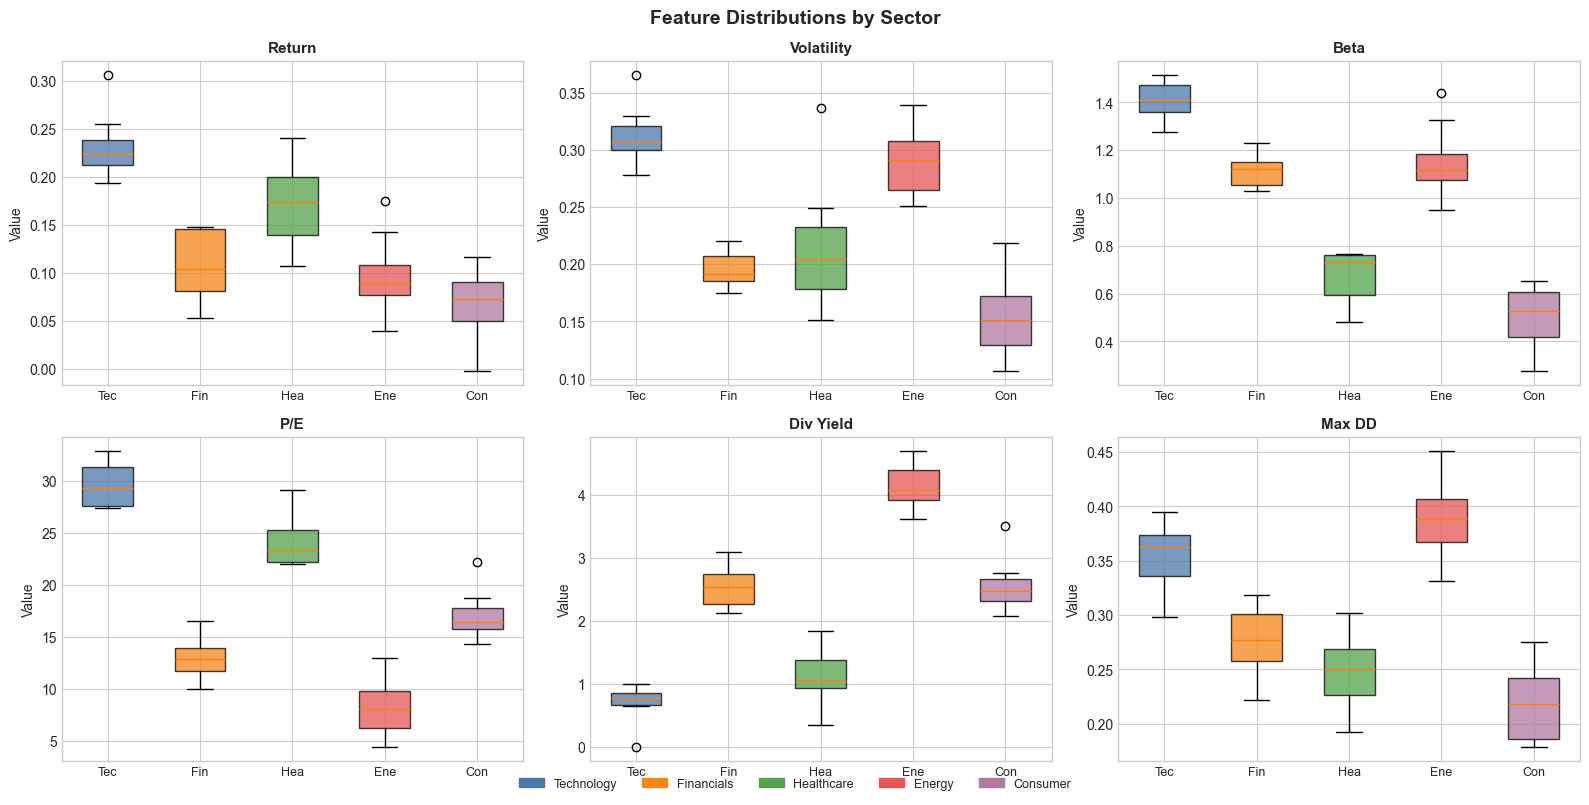

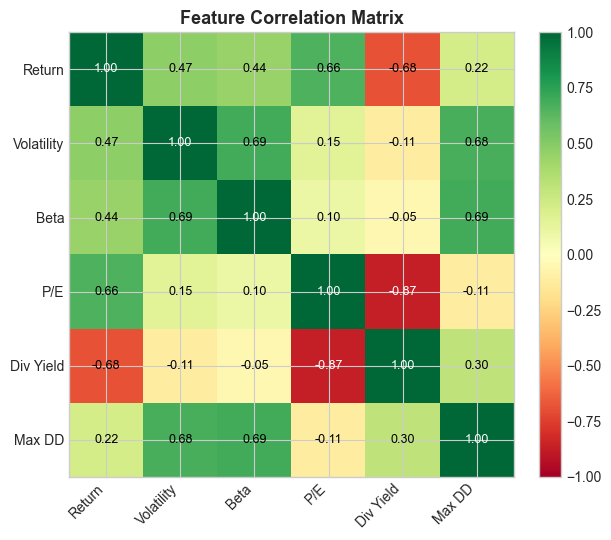

In [5]:
# ── Feature distributions by sector (boxplots) ──
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat, lbl in zip(axes.flatten(), FEATURES, FEAT_LABELS):
    data_by_sector = [df.loc[df["sector"] == s, feat].values for s in SECTORS]
    bp = ax.boxplot(data_by_sector, patch_artist=True, notch=False, widths=0.55)
    for patch, sec in zip(bp["boxes"], SECTORS):
        patch.set_facecolor(SECTOR_COLORS[sec])
        patch.set_alpha(0.75)
    ax.set_title(lbl, fontsize=11, fontweight="bold")
    ax.set_xticks(range(1, len(SECTORS) + 1))
    ax.set_xticklabels([s[:3] for s in SECTORS], fontsize=9)
    ax.set_ylabel("Value")

patches = [mpatches.Patch(color=SECTOR_COLORS[s], label=s) for s in SECTORS]
fig.legend(handles=patches, loc="lower center", ncol=5, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Feature Distributions by Sector", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# ── Correlation heatmap ──
corr = pd.DataFrame(df[FEATURES].values, columns=FEAT_LABELS).corr()
fig2, ax2 = plt.subplots(figsize=(7, 5.5))
im = ax2.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax2.set_xticks(range(len(FEAT_LABELS)))
ax2.set_xticklabels(FEAT_LABELS, rotation=45, ha="right")
ax2.set_yticks(range(len(FEAT_LABELS)))
ax2.set_yticklabels(FEAT_LABELS)
for i in range(len(FEAT_LABELS)):
    for j in range(len(FEAT_LABELS)):
        v = corr.values[i, j]
        ax2.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                 color="white" if abs(v) > 0.7 else "black")
fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
fig2.tight_layout()
plt.show()


## 2. Feature Selection and Standardisation

### Why we use these 6 features
We want features that capture **different dimensions of a stock's risk/return profile**. Using correlated features (e.g., both return and Sharpe ratio) would double-count the same signal.

| Feature | Dimension captured |
|---|---|
| `annual_return` | Return level |
| `volatility` | Total risk (dispersion) |
| `beta` | Systematic / market risk |
| `pe_ratio` | Valuation (growth vs value) |
| `dividend_yield` | Income profile |
| `max_drawdown` | Tail / downside risk |

### Why standardisation is essential

Most clustering algorithms (K-Means, DBSCAN, Hierarchical) use **Euclidean distance**. If you leave features on their raw scales:

- `pe_ratio` ranges ~5–40 → dominates every distance calculation
- `annual_return` ranges ~0.05–0.30 → almost invisible

**StandardScaler** transforms each feature to mean = 0, standard deviation = 1:

$$z = \frac{x - \mu}{\sigma}$$

After scaling, every feature contributes equally to distances. The algorithm cannot be "fooled" by a feature that simply has large absolute numbers.

> **Rule of thumb:** Always standardise before applying any distance-based algorithm. Tree-based models (Random Forest, XGBoost) do not need scaling, but clustering does.


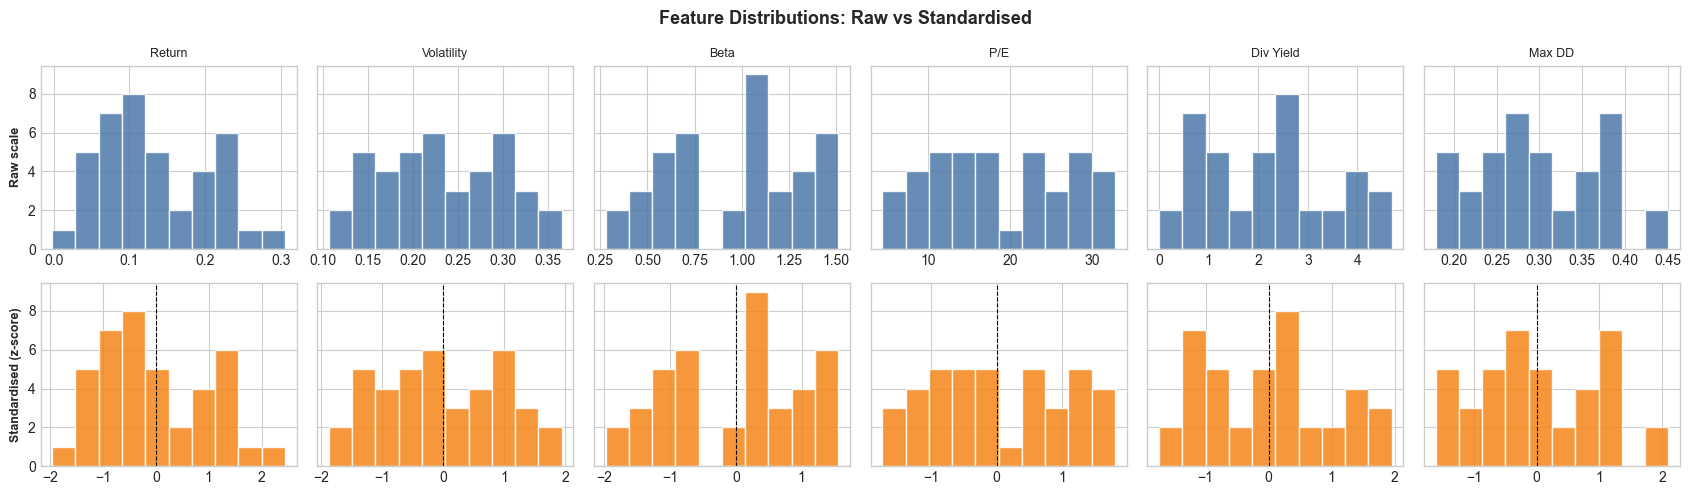

Feature statistics after standardisation (should be ~0 mean, ~1 std):


,Return,Volatility,Beta,P/E,Div Yield,Max DD
mean,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000
std,1.0127,1.0127,1.0127,1.0127,1.0127,1.0127


In [6]:
scaler = StandardScaler()
X_raw  = df[FEATURES].values
X_sc   = scaler.fit_transform(X_raw)

# ── Before / After distribution comparison ──
fig, axes = plt.subplots(2, 6, figsize=(17, 5), sharey="row")
for j, (feat, lbl) in enumerate(zip(FEATURES, FEAT_LABELS)):
    axes[0, j].hist(X_raw[:, j], bins=10, color="#4C78A8", edgecolor="white", alpha=0.85)
    axes[0, j].set_title(lbl, fontsize=9)
    axes[1, j].hist(X_sc[:, j],  bins=10, color="#F58518", edgecolor="white", alpha=0.85)
    axes[1, j].axvline(0, color="black", linewidth=0.8, linestyle="--")

axes[0, 0].set_ylabel("Raw scale", fontsize=9, fontweight="bold")
axes[1, 0].set_ylabel("Standardised (z-score)", fontsize=9, fontweight="bold")
fig.suptitle("Feature Distributions: Raw vs Standardised", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("Feature statistics after standardisation (should be ~0 mean, ~1 std):")
stat_df = pd.DataFrame(X_sc, columns=FEAT_LABELS).describe().loc[["mean", "std"]]
display(stat_df)


## 3. Dimensionality Reduction with PCA

We have 6 features — a 6-dimensional space. Humans can only visualise 2D or 3D. **Principal Component Analysis (PCA)** solves this by finding new axes (principal components) that capture the most variance.

### How PCA works — intuition

Imagine all 40 stocks as points in a 6D cloud. PCA finds the **direction of maximum spread** (PC1), then the direction of maximum remaining spread that is perpendicular to PC1 (PC2), and so on.

$$\text{PC1} = w_1 \cdot \text{Return} + w_2 \cdot \text{Vol} + w_3 \cdot \text{Beta} + \ldots$$

The weights $w_i$ are called **loadings**. A large loading magnitude means that feature is important for that component.

### What the three charts show

| Chart | What to look at |
|---|---|
| **Scree plot** | Bars show variance explained per component; red line is cumulative. Choose the number of components where cumulative reaches ~80%. |
| **Biplot** | Stocks as coloured dots in PC1-PC2 space. Arrows are loading vectors. Arrows pointing in the same direction indicate correlated features. Long arrows = the feature strongly influences that direction. |
| **Loadings heatmap** | Exact loading values for the first 3 PCs. Red = positive contribution, blue = negative. |

### Reading the biplot
- Dots that are **far apart** are financially dissimilar; dots **close together** are similar.
- If two arrows point in the same direction (e.g., Return and Sharpe), those features are correlated.
- If arrows point in **opposite directions** (e.g., Dividend Yield vs Return), higher values of one correspond to lower values of the other.
- Stocks in the direction of a long arrow tend to have **high values** for that feature.


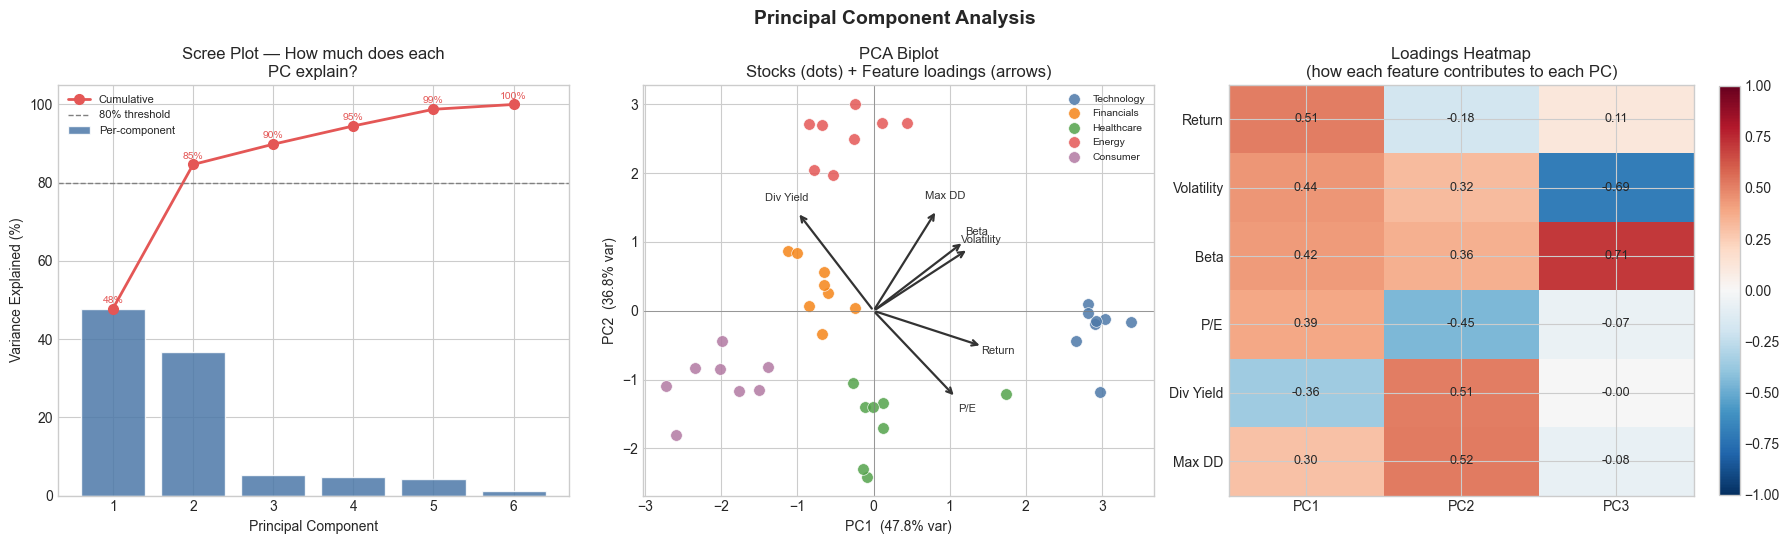

PC1 + PC2 capture 84.7% of total variance.
PC1 + PC2 + PC3 capture 89.8% — used for 3-D plots if needed.


In [7]:
pca    = PCA(n_components=6)
PC_ALL = pca.fit_transform(X_sc)
PC2    = PC_ALL[:, :2]          # first two PCs used for all scatter plots

evr = pca.explained_variance_ratio_
cev = np.cumsum(evr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# ── Scree plot ──
ax = axes[0]
ax.bar(range(1, 7), evr * 100, color="#4C78A8", edgecolor="white", alpha=0.85, label="Per-component")
ax.plot(range(1, 7), cev * 100, "o-", color="#E45756", linewidth=2, markersize=7, label="Cumulative")
ax.axhline(80, color="grey", linestyle="--", linewidth=1, label="80% threshold")
ax.set_xticks(range(1, 7))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("Scree Plot — How much does each\nPC explain?")
ax.legend(fontsize=8)
for i, v in enumerate(cev * 100):
    ax.text(i + 1, v + 1.5, f"{v:.0f}%", ha="center", fontsize=7.5, color="#E45756")

# ── Biplot ──
ax = axes[1]
for sec in SECTORS:
    mask = df["sector"] == sec
    ax.scatter(PC2[mask, 0], PC2[mask, 1], label=sec,
               color=SECTOR_COLORS[sec], s=70, alpha=0.85, edgecolors="white", linewidths=0.5)
loadings = pca.components_[:2].T   # shape (6, 2)
scale    = 2.8
for k, lbl in enumerate(FEAT_LABELS):
    lx, ly = loadings[k, 0] * scale, loadings[k, 1] * scale
    ax.annotate("", xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.6))
    ax.text(lx * 1.14, ly * 1.14, lbl, fontsize=8, ha="center", va="center", color="#333333")
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel(f"PC1  ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({evr[1]*100:.1f}% var)")
ax.set_title("PCA Biplot\nStocks (dots) + Feature loadings (arrows)")
ax.legend(fontsize=7.5, loc="best")

# ── Loadings heatmap ──
ax = axes[2]
load_df = pd.DataFrame(pca.components_[:3].T, index=FEAT_LABELS, columns=["PC1", "PC2", "PC3"])
im = ax.imshow(load_df.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["PC1", "PC2", "PC3"])
ax.set_yticks(range(len(FEAT_LABELS)))
ax.set_yticklabels(FEAT_LABELS)
for i in range(len(FEAT_LABELS)):
    for j in range(3):
        ax.text(j, i, f"{load_df.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Loadings Heatmap\n(how each feature contributes to each PC)")

fig.suptitle("Principal Component Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"PC1 + PC2 capture {cev[1]*100:.1f}% of total variance.")
print(f"PC1 + PC2 + PC3 capture {cev[2]*100:.1f}% — used for 3-D plots if needed.")


## 4. K-Means Clustering

K-Means is the most widely used clustering algorithm. Given a chosen number of clusters $k$, it:

1. Randomly places $k$ **centroids** (cluster centres) in the feature space.
2. Assigns each stock to its nearest centroid.
3. Moves each centroid to the **mean** of all stocks assigned to it.
4. Repeats steps 2–3 until the assignments stop changing.

The algorithm minimises **inertia** — the total sum of squared distances from each point to its cluster centroid:

$$\text{Inertia} = \sum_{i=1}^{n} \| x_i - \mu_{c(i)} \|^2$$

### Choosing k: Elbow method and Silhouette score

You must tell K-Means how many clusters to use. Two tools help:

| Tool | What it shows | How to use it |
|---|---|---|
| **Elbow plot** | Inertia vs $k$ | Find where adding one more cluster gives rapidly diminishing returns — the "elbow" bend |
| **Silhouette score** | Compactness vs separation, range $[-1, 1]$ | Higher is better; pick the $k$ that maximises it |

### Pros and Cons for Finance

| Pro | Con |
|---|---|
| Fast and scalable | Must choose k in advance |
| Easy to interpret centroid profiles | Assumes spherical, equal-sized clusters |
| Stable with standardised data | Sensitive to initialisation (use `n_init=10`) |
| Great for portfolio bucketing | Does not detect outliers — all points assigned |


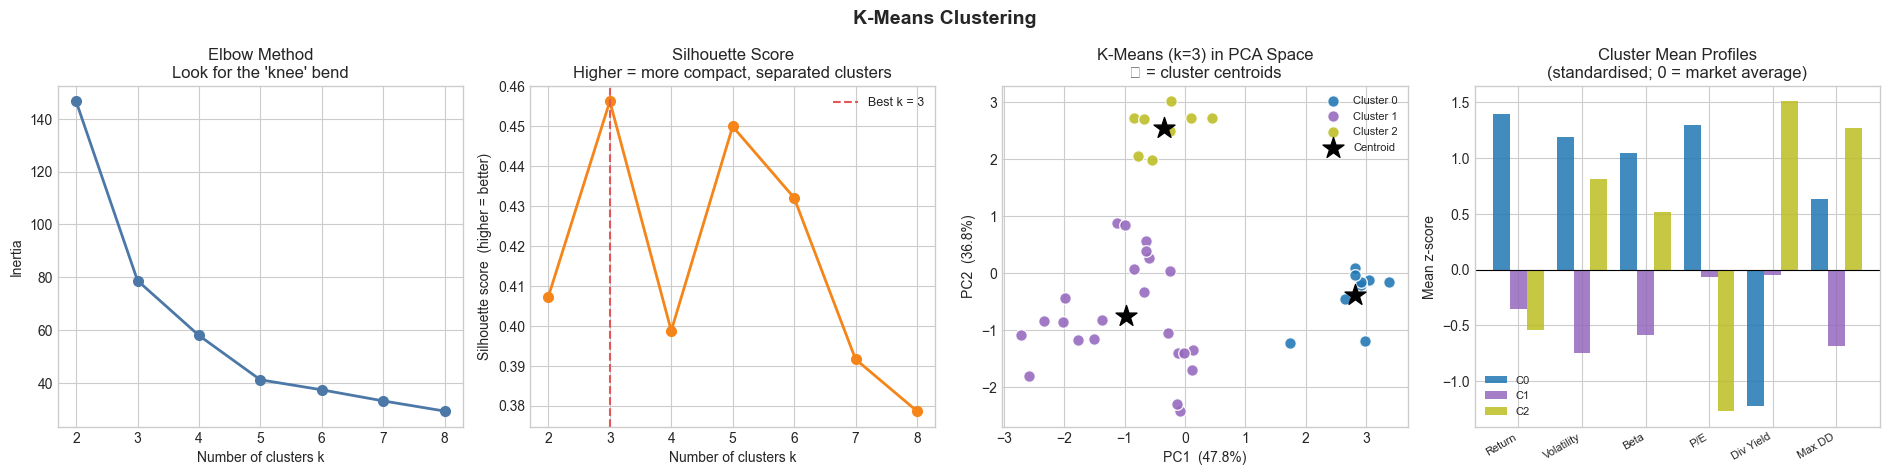


K-Means cluster ↔ sector cross-tabulation:
K-Means cluster  0  1  2
Sector                  
Consumer         0  8  0
Energy           0  0  8
Financials       0  8  0
Healthcare       1  7  0
Technology       8  0  0


In [8]:
# ── Elbow + Silhouette curve ──
k_range     = range(2, 9)
inertias    = []
sil_scores  = []

for k in k_range:
    km_tmp  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_tmp = km_tmp.fit_predict(X_sc)
    inertias.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl_tmp))

best_k = list(k_range)[int(np.argmax(sil_scores))]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))

axes[0].plot(list(k_range), inertias, "o-", color="#4C78A8", linewidth=2, markersize=7)
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method\nLook for the 'knee' bend")

axes[1].plot(list(k_range), sil_scores, "o-", color="#F58518", linewidth=2, markersize=7)
axes[1].axvline(best_k, color="#E45756", linestyle="--", linewidth=1.5, label=f"Best k = {best_k}")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score  (higher = better)")
axes[1].set_title("Silhouette Score\nHigher = more compact, separated clusters")
axes[1].legend(fontsize=9)

# ── Fit final K-Means ──
K_OPT   = best_k
km      = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
km_lbl  = km.fit_predict(X_sc)
df["km_cluster"] = km_lbl
C_COLORS = plt.cm.tab10(np.linspace(0, 0.85, K_OPT))

# ── PCA scatter ──
for c in range(K_OPT):
    m = km_lbl == c
    axes[2].scatter(PC2[m, 0], PC2[m, 1], color=C_COLORS[c],
                    label=f"Cluster {c}", s=70, alpha=0.88, edgecolors="white")
# Mark centroids
km_centroids_pc = pca.transform(km.cluster_centers_)[:, :2]
axes[2].scatter(km_centroids_pc[:, 0], km_centroids_pc[:, 1],
                marker="*", s=250, c="black", zorder=6, label="Centroid")
axes[2].set_xlabel(f"PC1  ({evr[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2  ({evr[1]*100:.1f}%)")
axes[2].set_title(f"K-Means (k={K_OPT}) in PCA Space\n★ = cluster centroids")
axes[2].legend(fontsize=8)

# ── Cluster mean profiles ──
prof_df = pd.DataFrame(X_sc, columns=FEAT_LABELS)
prof_df["cluster"] = km_lbl
means   = prof_df.groupby("cluster")[FEAT_LABELS].mean()
x       = np.arange(len(FEAT_LABELS))
w       = 0.80 / K_OPT
for c in range(K_OPT):
    axes[3].bar(x + c * w - (K_OPT - 1) * w / 2,
                means.iloc[c], width=w, label=f"C{c}", color=C_COLORS[c], alpha=0.85)
axes[3].set_xticks(x)
axes[3].set_xticklabels(FEAT_LABELS, rotation=30, ha="right", fontsize=8)
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("Mean z-score")
axes[3].set_title("Cluster Mean Profiles\n(standardised; 0 = market average)")
axes[3].legend(fontsize=8)

fig.suptitle("K-Means Clustering", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

print("\nK-Means cluster ↔ sector cross-tabulation:")
print(pd.crosstab(df["sector"], df["km_cluster"],
                  rownames=["Sector"], colnames=["K-Means cluster"]))


### How to read the K-Means charts

**Panel 1 — Elbow plot:**
- x-axis: number of clusters $k$ (from 2 to 8)
- y-axis: inertia (total within-cluster variance)
- Look for a **sharp bend** where the curve flattens — adding more clusters beyond that point gives little improvement. If there is no clear bend, silhouette is more reliable.

**Panel 2 — Silhouette score:**
- A score of **+1** means each stock is much closer to its own cluster than to any neighbour cluster — perfect separation.
- A score near **0** means stocks are right on the cluster boundary.
- A score of **-1** means a stock would fit better in a different cluster — an assignment error.
- Pick the $k$ with the **highest silhouette score** (red dashed line).

**Panel 3 — PCA scatter:**
- Each coloured dot is a stock projected onto PC1–PC2.
- Stars (**★**) mark the cluster centroids — the average position of all stocks in that cluster.
- Well-separated clusters with little mixing = a good solution.
- Overlapping clusters suggest the data boundary is ambiguous at that location.

**Panel 4 — Cluster mean profiles:**
- Each bar is the average standardised value of a feature for that cluster.
- Bars above 0: this cluster has above-average values for that feature.
- Bars below 0: below-average.
- Use this to **name** clusters: e.g., a cluster with high Return, high Vol, high Beta = "Aggressive Growth"; low Vol, high Dividend = "Defensive Income".


## 5. Hierarchical Clustering

Hierarchical clustering builds a **tree of merges** (a dendrogram) rather than jumping straight to a fixed number of clusters. This gives you a much richer picture: you can cut the tree at any level to get 2, 3, 4… clusters, all from a single fit.

### How it works (agglomerative / bottom-up)

1. Start: every stock is its own cluster (40 clusters).
2. Merge the two most similar clusters into one.
3. Repeat until there is only one cluster left.
4. Cut the tree at a chosen height to read off flat cluster assignments.

### Linkage methods — how "similarity" is measured

| Linkage | Merges based on | Best for |
|---|---|---|
| **Ward** (we use this) | Minimises increase in total within-cluster variance | Compact, evenly-sized clusters — recommended for finance |
| Complete | Maximum distance between any two points across clusters | Avoids elongated chains |
| Average | Average distance between all cross-cluster pairs | Balanced |
| Single | Minimum distance (nearest neighbour) | Detects chains; sensitive to outliers |

### Reading the dendrogram
- The **x-axis** lists individual stocks (leaves at the bottom).
- The **y-axis** is the merge distance (Ward linkage = increase in total within-cluster variance).
- A **horizontal bar at height $h$** connects two clusters that merge at distance $h$.
- To get $k$ clusters, draw a **horizontal cut line** across the dendrogram — count how many vertical lines it crosses. Each vertical line below the cut = one cluster.
- **Colour** (by sector) on the x-tick labels helps you see whether the algorithm recovered meaningful financial groups.

### Why it is useful in finance
- No need to specify $k$ upfront — explore the full hierarchy first.
- **Portfolio construction**: cut at a level that gives the number of risk buckets you want.
- **Sector classification**: check whether the tree aligns with GICS/SIC sectors.


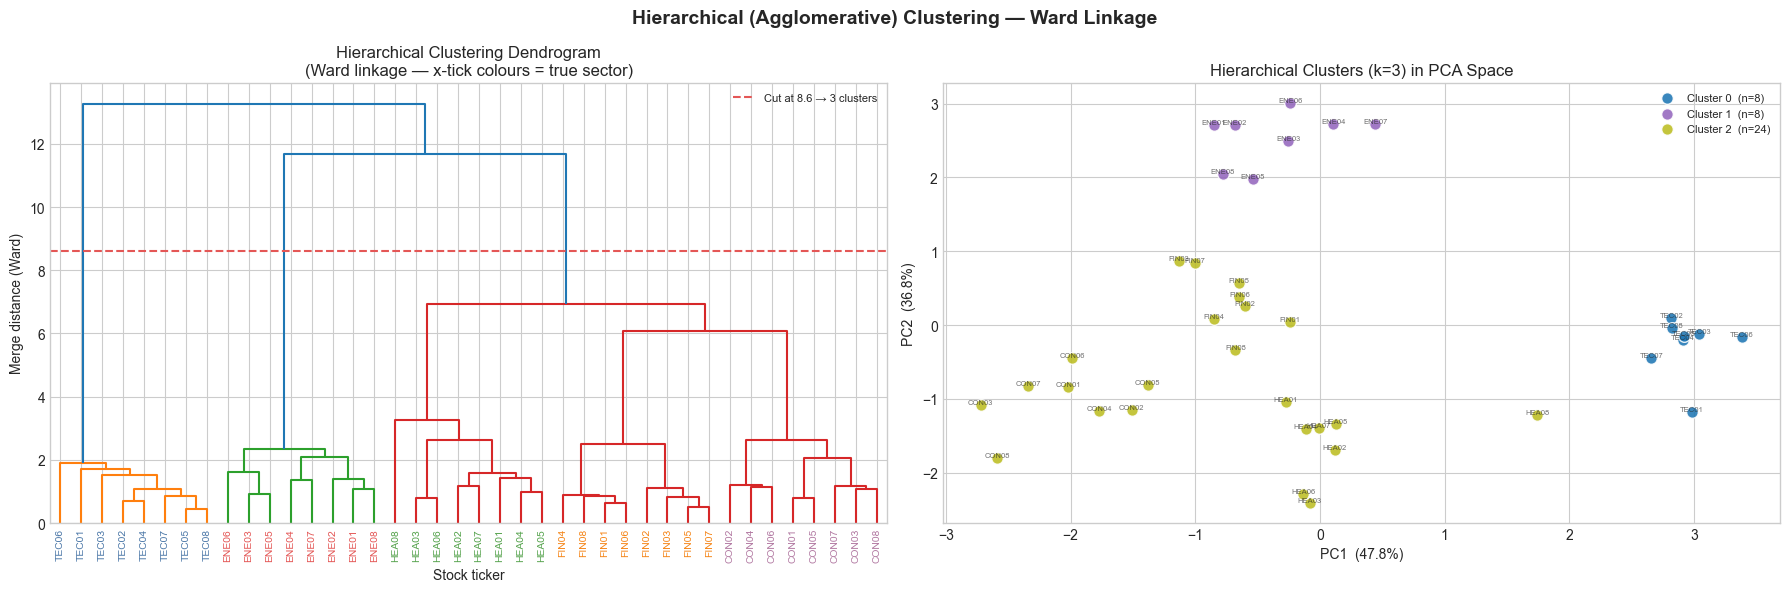

Hierarchical silhouette score (k=3): 0.4439

Hierarchical cluster ↔ sector cross-tabulation:
HC cluster  0  1  2
Sector             
Consumer    0  0  8
Energy      0  8  0
Financials  0  0  8
Healthcare  0  0  8
Technology  8  0  0


In [9]:
# ── Build linkage matrix with Ward method ──
Z = linkage(X_sc, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Dendrogram ──
cut_height = 0.65 * max(Z[:, 2])
dn = dendrogram(
    Z,
    labels=df["ticker"].values,
    ax=axes[0],
    color_threshold=cut_height,
    leaf_rotation=90,
    leaf_font_size=7.5,
)
axes[0].axhline(cut_height, color="#E45756", linestyle="--", linewidth=1.5,
                label=f"Cut at {cut_height:.1f} → {K_OPT} clusters")
axes[0].set_title("Hierarchical Clustering Dendrogram\n(Ward linkage — x-tick colours = true sector)")
axes[0].set_xlabel("Stock ticker")
axes[0].set_ylabel("Merge distance (Ward)")
axes[0].legend(fontsize=8)

# Colour x-tick labels by true sector
for tick in axes[0].get_xticklabels():
    t = tick.get_text()
    sec = df.loc[df["ticker"] == t, "sector"].values[0]
    tick.set_color(SECTOR_COLORS[sec])

# ── Flat cluster assignments + PCA scatter ──
hc_lbl = fcluster(Z, t=K_OPT, criterion="maxclust") - 1   # 0-indexed
df["hc_cluster"] = hc_lbl

for c in range(K_OPT):
    m = hc_lbl == c
    axes[1].scatter(PC2[m, 0], PC2[m, 1], color=C_COLORS[c],
                    label=f"Cluster {c}  (n={m.sum()})", s=70,
                    alpha=0.88, edgecolors="white")

# Annotate with tickers
for i, row in df.iterrows():
    axes[1].annotate(row["ticker"], (PC2[i, 0], PC2[i, 1]),
                     fontsize=5.5, ha="center", va="bottom", alpha=0.65)

axes[1].set_xlabel(f"PC1  ({evr[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2  ({evr[1]*100:.1f}%)")
axes[1].set_title(f"Hierarchical Clusters (k={K_OPT}) in PCA Space")
axes[1].legend(fontsize=8)

fig.suptitle("Hierarchical (Agglomerative) Clustering — Ward Linkage", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

sil_hc = silhouette_score(X_sc, hc_lbl)
print(f"Hierarchical silhouette score (k={K_OPT}): {sil_hc:.4f}")
print("\nHierarchical cluster ↔ sector cross-tabulation:")
print(pd.crosstab(df["sector"], df["hc_cluster"],
                  rownames=["Sector"], colnames=["HC cluster"]))


## 6. DBSCAN: Density-Based Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) discovers clusters by finding **dense regions** in the feature space, separated by sparse regions. It does **not** require you to specify the number of clusters in advance — it infers it from the data structure.

### How it works

Two parameters control everything:
- **`eps`** (ε): the radius of the neighbourhood around each point.
- **`min_samples`**: the minimum number of points in a neighbourhood to form a "core point".

A point is classified as:
| Type | Rule | What it means |
|---|---|---|
| **Core point** | Has ≥ `min_samples` neighbours within ε | The dense interior of a cluster |
| **Border point** | Within ε of a core point, but not core itself | The edge of a cluster |
| **Noise point** (−1) | Not reachable from any core point | Outlier — does not belong to any cluster |

### Choosing `eps` — the k-NN distance plot
Sort all points by their distance to the $k$-th nearest neighbour. Plot this sorted distance. The **elbow** of the curve is a good estimate for `eps` — below it, points are in a dense region; above it, they become outliers.

### Why DBSCAN is valuable in finance

| Advantage | Finance use case |
|---|---|
| Finds arbitrarily shaped clusters | Return distributions are non-elliptical |
| Flags noise points as outliers | Detect anomalous stocks / suspicious transactions |
| No need to set $k$ | Less assumption about market structure |

| Disadvantage | Mitigation |
|---|---|
| Sensitive to `eps` and `min_samples` | Use k-NN plot + domain knowledge |
| Struggles with varying density | Try HDBSCAN for richer datasets |


DBSCAN found 4 cluster(s) and 1 noise point(s)  (eps=1.5, min_samples=3)


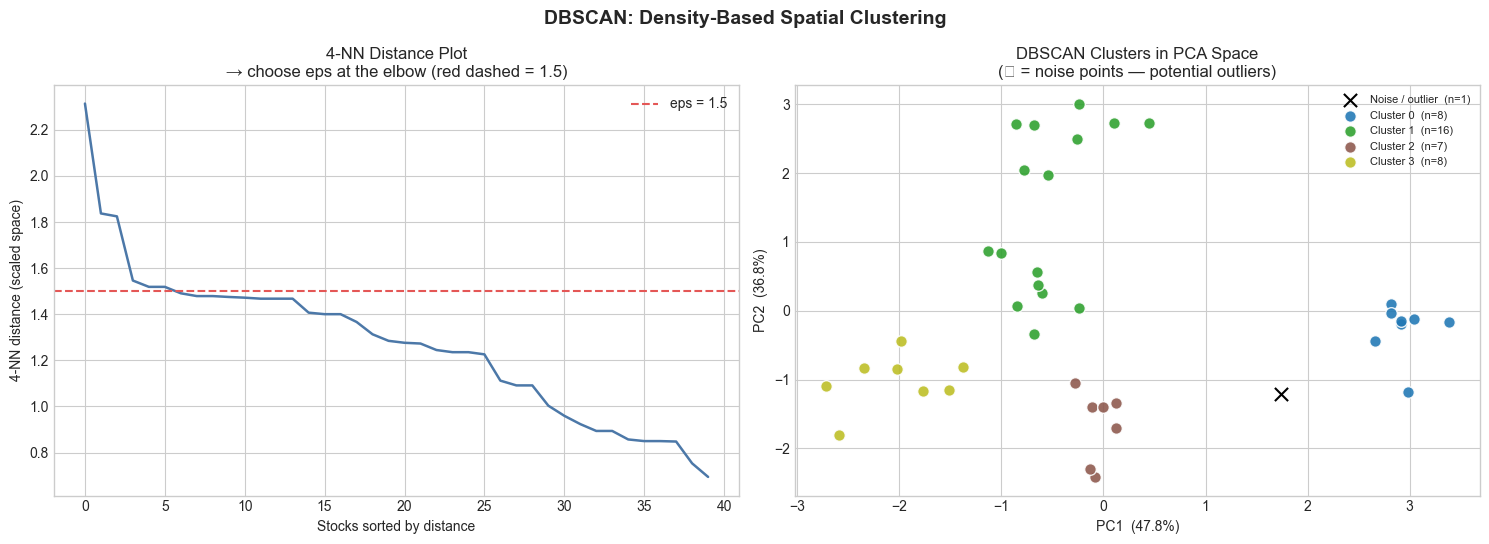


Noise points (potential outliers):


,ticker,sector,annual_return,volatility,beta,pe_ratio,dividend_yield,max_drawdown
23,HEA08,Healthcare,0.2399,0.3366,0.7622,22.0314,0.3472,0.2607


In [10]:
# ── k-NN distance plot to choose eps ──
K_NN  = 4
nbrs  = NearestNeighbors(n_neighbors=K_NN).fit(X_sc)
dists, _ = nbrs.kneighbors(X_sc)
k_dist   = np.sort(dists[:, -1])[::-1]     # descending

# Auto-detect elbow as 85th percentile
eps_auto = float(np.percentile(k_dist, 85))
EPS      = round(eps_auto, 1)
MIN_SAMP = 3

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(k_dist, color="#4C78A8", linewidth=1.8)
axes[0].axhline(EPS, color="#E45756", linestyle="--", linewidth=1.5, label=f"eps = {EPS}")
axes[0].set_title(f"{K_NN}-NN Distance Plot\n→ choose eps at the elbow (red dashed = {EPS})")
axes[0].set_xlabel("Stocks sorted by distance")
axes[0].set_ylabel(f"{K_NN}-NN distance (scaled space)")
axes[0].legend()

# ── Fit DBSCAN ──
db      = DBSCAN(eps=EPS, min_samples=MIN_SAMP).fit(X_sc)
db_lbl  = db.labels_
df["db_cluster"] = db_lbl

n_cl_db  = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
n_noise  = (db_lbl == -1).sum()
print(f"DBSCAN found {n_cl_db} cluster(s) and {n_noise} noise point(s)  "
      f"(eps={EPS}, min_samples={MIN_SAMP})")

unique_lbl  = sorted(set(db_lbl))
db_cl_lbl   = [l for l in unique_lbl if l != -1]
db_c_colors = plt.cm.tab10(np.linspace(0, 0.85, max(len(db_cl_lbl), 1)))
db_col_map  = {l: db_c_colors[i] for i, l in enumerate(db_cl_lbl)}

for label in unique_lbl:
    m = db_lbl == label
    if label == -1:
        axes[1].scatter(PC2[m, 0], PC2[m, 1], c="black", marker="x",
                        s=90, linewidths=1.5, label=f"Noise / outlier  (n={m.sum()})", zorder=6)
    else:
        axes[1].scatter(PC2[m, 0], PC2[m, 1], color=db_col_map[label],
                        label=f"Cluster {label}  (n={m.sum()})", s=70,
                        alpha=0.88, edgecolors="white")

axes[1].set_xlabel(f"PC1  ({evr[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2  ({evr[1]*100:.1f}%)")
axes[1].set_title(f"DBSCAN Clusters in PCA Space\n(✕ = noise points — potential outliers)")
axes[1].legend(fontsize=8)

fig.suptitle("DBSCAN: Density-Based Spatial Clustering", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# Show noise point details
noise_stocks = df[db_lbl == -1][["ticker", "sector"] + FEATURES]
if len(noise_stocks):
    print("\nNoise points (potential outliers):")
    display(noise_stocks)


## 7. Gaussian Mixture Models (GMM) — Soft Clustering

GMM assumes the data is generated by a mixture of $k$ Gaussian (normal) distributions. Unlike K-Means — which assigns each stock to exactly one cluster — GMM gives each stock a **probability of belonging to each cluster**.

$$P(\text{stock } x \text{ belongs to cluster } c) \in [0, 1], \quad \sum_c P = 1$$

This is called **soft assignment** and is more realistic for financial data, where a stock can genuinely exhibit characteristics of multiple sectors.

### The BIC criterion — choosing the number of components

The **Bayesian Information Criterion (BIC)** penalises model complexity:

$$\text{BIC} = -2 \ln(\hat{L}) + p \ln(n)$$

where $\hat{L}$ is the model likelihood, $p$ is the number of parameters, and $n$ is the number of data points. **Lower BIC is better.** The BIC penalises adding too many components (overfitting).

### Understanding the ellipses in the PCA scatter
Each Gaussian component has a **mean** (centre) and a **covariance matrix** (shape and orientation). The dashed ellipses drawn in PCA space are the **1.5σ confidence boundaries** — roughly 87% of points in that component fall inside the ellipse.

- A **round ellipse** = the component is equally spread in all directions.
- An **elongated ellipse** = the component is stretched along a particular axis (features are correlated within that group).

### GMM vs K-Means

| Feature | K-Means | GMM |
|---|---|---|
| Assignment | Hard (one cluster) | Soft (probability per cluster) |
| Cluster shape | Spherical (distance-based) | Elliptical (covariance-based) |
| Overlapping clusters | Poor | Handles naturally |
| Finance use | Portfolio bucketing | Risk factor estimation, regime models |


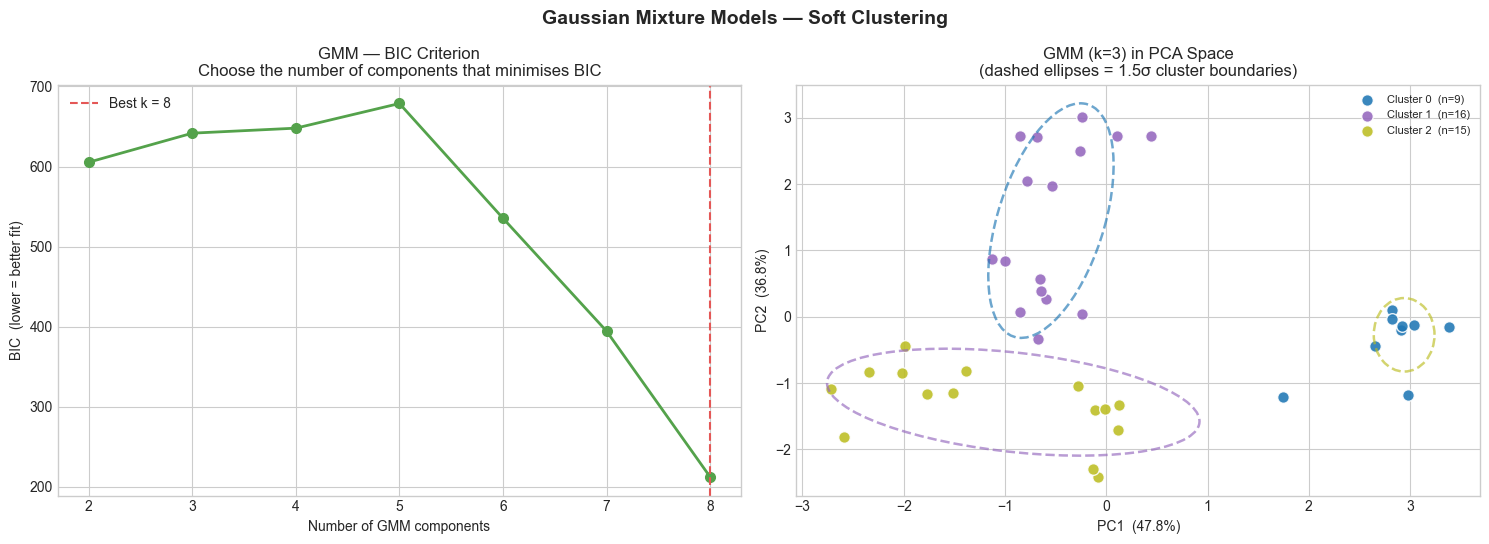

Stocks with most uncertain membership (lowest max probability):


,P(C0),P(C1),P(C2),hard_label,max_prob
ticker,,,,,
CON04,0.0000,0.0001,0.9999,2,0.9999
CON02,0.0000,0.0000,1.0000,2,1.0000
CON06,0.0000,0.0000,1.0000,2,1.0000
CON05,0.0000,0.0000,1.0000,2,1.0000
HEA08,1.0000,0.0000,0.0000,0,1.0000
HEA01,0.0000,0.0000,1.0000,2,1.0000
FIN02,0.0000,1.0000,0.0000,1,1.0000
HEA03,0.0000,0.0000,1.0000,2,1.0000


In [11]:
def draw_ellipse(ax, mean, cov, n_std, color, alpha=0.65):
    """Draw a confidence ellipse given a 2D mean and 2x2 covariance matrix."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(max(eigenvalues[0], 0))
    height = 2 * n_std * np.sqrt(max(eigenvalues[1], 0))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, fc="none", linewidth=1.8, linestyle="--", alpha=alpha)
    ax.add_patch(ell)


# ── BIC score to select number of components ──
bic_scores = []
for k in range(2, 9):
    gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
    gmm_k.fit(X_sc)
    bic_scores.append(gmm_k.bic(X_sc))

best_k_gmm = range(2, 9)[int(np.argmin(bic_scores))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(range(2, 9), bic_scores, "o-", color="#54A24B", linewidth=2, markersize=7)
axes[0].axvline(best_k_gmm, color="#E45756", linestyle="--", linewidth=1.5,
                label=f"Best k = {best_k_gmm}")
axes[0].set_xlabel("Number of GMM components")
axes[0].set_ylabel("BIC  (lower = better fit)")
axes[0].set_title("GMM — BIC Criterion\nChoose the number of components that minimises BIC")
axes[0].legend()

# ── Fit GMM on full scaled data; fit 2D GMM on PC2 for ellipse visualisation ──
GMM_K   = K_OPT
gmm     = GaussianMixture(n_components=GMM_K, covariance_type="full", random_state=42, n_init=5)
gmm.fit(X_sc)
gmm_lbl = gmm.predict(X_sc)
df["gmm_cluster"] = gmm_lbl

gmm_pc2 = GaussianMixture(n_components=GMM_K, covariance_type="full", random_state=42, n_init=5)
gmm_pc2.fit(PC2)

# Scatter
for c in range(GMM_K):
    m = gmm_lbl == c
    axes[1].scatter(PC2[m, 0], PC2[m, 1], color=C_COLORS[c],
                    label=f"Cluster {c}  (n={m.sum()})", s=70, alpha=0.88, edgecolors="white")

# Draw 1.5σ confidence ellipses in PC1–PC2 space
for c in range(GMM_K):
    draw_ellipse(axes[1], gmm_pc2.means_[c], gmm_pc2.covariances_[c], 1.5, C_COLORS[c])

axes[1].set_xlabel(f"PC1  ({evr[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2  ({evr[1]*100:.1f}%)")
axes[1].set_title(f"GMM (k={GMM_K}) in PCA Space\n(dashed ellipses = 1.5σ cluster boundaries)")
axes[1].legend(fontsize=8)

fig.suptitle("Gaussian Mixture Models — Soft Clustering", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# ── Top-3 membership probabilities for each stock ──
probs = gmm.predict_proba(X_sc)
prob_df = pd.DataFrame(probs, columns=[f"P(C{c})" for c in range(GMM_K)], index=df["ticker"])
prob_df["hard_label"] = gmm_lbl
prob_df["max_prob"]   = probs.max(axis=1)
print("Stocks with most uncertain membership (lowest max probability):")
display(prob_df.sort_values("max_prob").head(8))


## 8. Algorithm Comparison

Now let's compare all four algorithms side-by-side on the same PCA projection and evaluate them with two metrics:

### Evaluation metrics

| Metric | What it measures | Range |
|---|---|---|
| **Silhouette score** | How well-separated and compact clusters are | $[-1, +1]$; higher is better |
| **Adjusted Rand Index (ARI)** | How closely cluster labels match the true sector labels | $[-1, +1]$; 0 = random, 1 = perfect match |

> ARI is only available here because we have synthetic data with known sector labels. In real unsupervised applications you would only have the silhouette score.

### What to look for in the comparison
- **K-Means** and **Hierarchical** should look similar if the clusters are convex (roughly round) — they both minimise within-cluster variance.
- **DBSCAN** will look different: it may produce fewer or more clusters and will show noise points (✕).
- **GMM** may assign different boundaries because it uses elliptical covariance, not just distances.
- A **high silhouette** means clusters are well-separated. A **high ARI** means the algorithm recovered financially meaningful groups close to the true sectors.


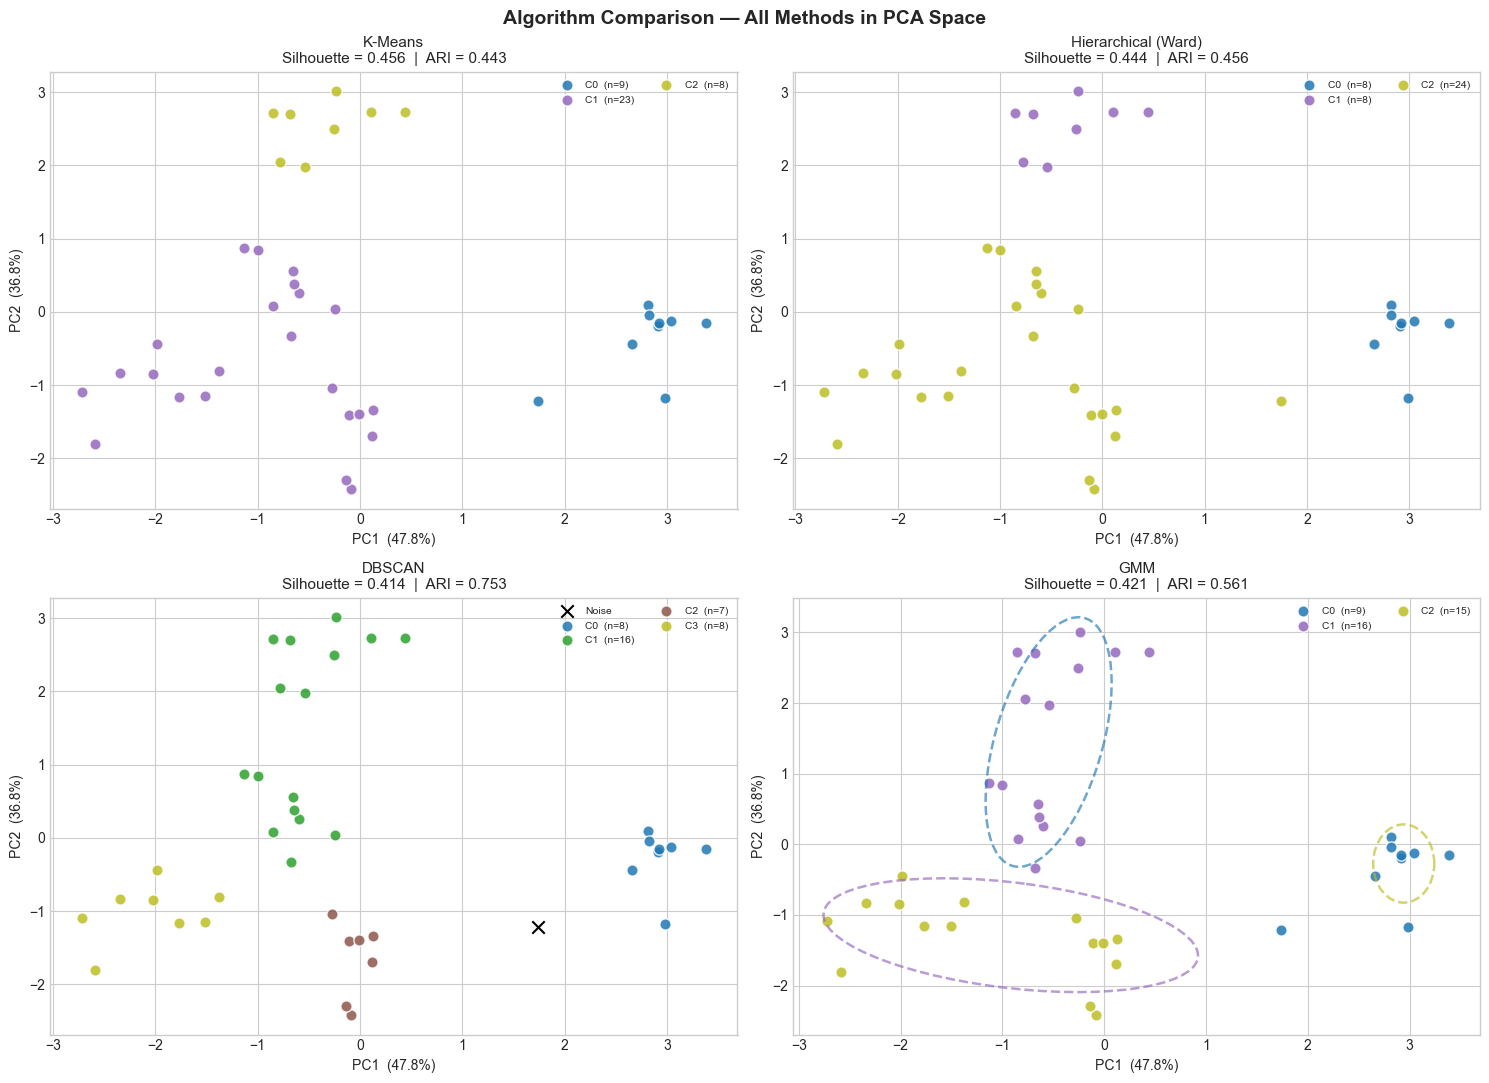

Algorithm Comparison Summary:


,Algorithm,# Clusters,# Noise points,Silhouette Score,ARI vs Sectors
0,K-Means,3,0,0.4562,0.4435
1,Hierarchical (Ward),3,0,0.4439,0.4558
2,DBSCAN,4,1,0.4142,0.7532
3,GMM,3,0,0.4215,0.5607


In [12]:
algo_names  = ["K-Means", "Hierarchical (Ward)", "DBSCAN", "GMM"]
label_cols  = ["km_cluster", "hc_cluster", "db_cluster", "gmm_cluster"]
true_labels = df["sector"].map(SECTOR_NUM).values

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for idx, (name, col) in enumerate(zip(algo_names, label_cols)):
    ax      = axes[idx]
    labels  = df[col].values
    uniq    = sorted(set(labels))
    cl_lbl  = [l for l in uniq if l != -1]
    cmap_c  = plt.cm.tab10(np.linspace(0, 0.85, max(len(cl_lbl), 1)))
    c_map   = {l: cmap_c[i] for i, l in enumerate(cl_lbl)}

    for label in uniq:
        m = labels == label
        if label == -1:
            ax.scatter(PC2[m, 0], PC2[m, 1], c="black", marker="x",
                       s=80, linewidths=1.5, label="Noise", zorder=6)
        else:
            ax.scatter(PC2[m, 0], PC2[m, 1], color=c_map[label],
                       label=f"C{label}  (n={m.sum()})", s=65,
                       alpha=0.85, edgecolors="white")

    # GMM: add ellipses
    if col == "gmm_cluster":
        for c in range(GMM_K):
            draw_ellipse(ax, gmm_pc2.means_[c], gmm_pc2.covariances_[c], 1.5, C_COLORS[c])

    # Compute metrics
    valid_mask = labels != -1
    valid_lbl  = labels[valid_mask]
    n_cl       = len(set(valid_lbl))
    sil = silhouette_score(X_sc[valid_mask], valid_lbl) if n_cl > 1 else float("nan")
    ari = adjusted_rand_score(true_labels[valid_mask], valid_lbl)

    ax.set_title(f"{name}\nSilhouette = {sil:.3f}  |  ARI = {ari:.3f}", fontsize=11)
    ax.set_xlabel(f"PC1  ({evr[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2  ({evr[1]*100:.1f}%)")
    ax.legend(fontsize=7.5, ncol=2)

fig.suptitle("Algorithm Comparison — All Methods in PCA Space", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# ── Summary table ──
summary_rows = []
for name, col in zip(algo_names, label_cols):
    labels     = df[col].values
    valid_mask = labels != -1
    valid_lbl  = labels[valid_mask]
    n_cl = len(set(valid_lbl))
    n_ns = (labels == -1).sum()
    sil  = silhouette_score(X_sc[valid_mask], valid_lbl) if n_cl > 1 else float("nan")
    ari  = adjusted_rand_score(true_labels[valid_mask], valid_lbl)
    summary_rows.append({
        "Algorithm":         name,
        "# Clusters":        n_cl,
        "# Noise points":    n_ns,
        "Silhouette Score":  round(sil, 4),
        "ARI vs Sectors":    round(ari, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print("Algorithm Comparison Summary:")
display(summary_df)


## Main Takeaways

### Core rules to remember

1. **Always standardise first.** Any distance-based algorithm (K-Means, DBSCAN, Hierarchical) will produce meaningless results on raw financial features with different scales. `StandardScaler` is almost always the right choice.

2. **PCA is for visualisation, not for clustering.** Fit your clustering algorithms on the full scaled feature matrix (6D here), and only use PCA to *plot* the results in 2D. Running K-Means on 2 PCs discards potentially valuable information.

3. **K-Means needs k upfront — use elbow + silhouette.** Neither the elbow plot nor the silhouette score alone is definitive. Use both, plus financial intuition about how many groups make sense.

4. **Hierarchical lets you explore the full tree.** If you are unsure how many clusters to use, fit the Ward dendrogram first — it shows you the full merge structure. Cut at different heights to explore 3, 4, or 5 groups without refitting.

5. **DBSCAN flags outliers for free.** Any stock labelled −1 deserves investigation: it may be a data error, an extremely unusual business model, or a genuine anomaly worth investigating for pairs trading or risk exclusion.

6. **GMM gives soft probabilities.** A stock with $P(C_1)=0.52$ and $P(C_2)=0.48$ is genuinely on the boundary. K-Means would force it into one group. In portfolio construction, borderline stocks deserve special attention or a smaller position.

7. **High ARI vs sectors ≠ always the goal.** GICS/SIC sectors are human-defined taxonomies. A clustering algorithm may find risk-based groups that cut across sectors and are *more* useful for portfolio diversification than the official classification.

8. **Cluster labels are arbitrary.** Cluster 0 in K-Means has no relationship to Cluster 0 in GMM. The numbers are just identifiers. Always validate cluster meaning by examining the centroid profiles.

---

### Beginner checklist — can you answer these?

- [ ] Why would K-Means give different results if you ran it on the raw (unscaled) data?
- [ ] A dendrogram has a long vertical bar (high merge distance) just before two main branches join. What does that suggest?
- [ ] A DBSCAN run returns 1 cluster and 35 noise points. What does that tell you about the choice of `eps`?
- [ ] If a stock has GMM probabilities of (0.51, 0.49), should you be confident in its cluster assignment? Why?
- [ ] You have 100 stocks and want to build 5 equal-risk buckets. Which algorithm is most suitable?

---

### Concepts to explore next

- **HDBSCAN** — hierarchical DBSCAN; better handles clusters of varying density and is more robust to `eps`
- **t-SNE and UMAP** — non-linear dimensionality reduction for visualisation of high-dimensional return data
- **Spectral clustering** — uses the graph Laplacian of the correlation matrix; popular for correlation-based portfolio clustering
- **Minimum Spanning Trees and Correlation Networks** — graph-based approaches for visualising the relationships between financial instruments
- **Dynamic clustering** — applying clustering to rolling windows of return data to detect regime changes
- **Validation without labels** — Calinski-Harabasz index, Davies-Bouldin score, and stability analysis across bootstrap samples
